### Wind farm power forecasting
This short notebook attempts to demonstrate a few basic concepts in data processing and machine learning. 
- Parsing and analyzing data
- Predicting power with a "persistence model" and a machine learning model (support vector machine).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_io import load_data
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from data_parsing import parse_data
from sklearn import svm
from sklearn.model_selection import TimeSeriesSplit
import warnings 
warnings.filterwarnings("ignore")

##### 1- Load and parse data

In [2]:
# Load files
files = [
    './inputs/Location1_train.csv', 
    './inputs/Location2_train.csv', 
    './inputs/Location3_train.csv', 
    './inputs/Location4_train.csv'
]

data = load_data(files)

Combined DataFrame Shape: (140160, 15)

First 5 rows:
                 Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0 2017-01-02 00:00:00      271.205556                   85   268.983333   
1 2017-01-02 01:00:00      271.150000                   86   269.094444   
2 2017-01-02 02:00:00      270.261111                   91   268.983333   
3 2017-01-02 03:00:00      270.594444                   88   268.872222   
4 2017-01-02 04:00:00      270.538889                   88   268.761111   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power   Location  wdcos_1

In [3]:
# Check for abnormal values (parsing data)
data_p = parse_data(data)

#### 2- plot time series

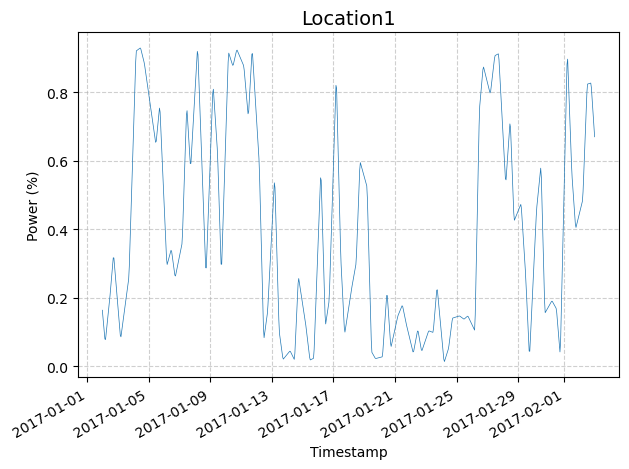

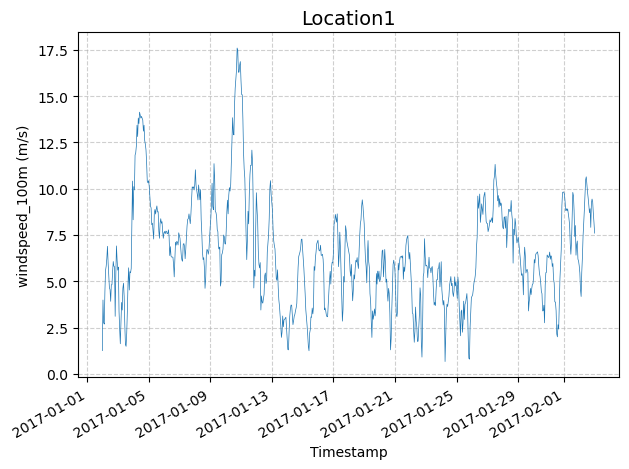

In [4]:
from plot_data import plot_location_data

Location = 'Location1'
time_s = '2017-01-02 00:00:00'
time_f = '2017-02-02 23:00:00'

plot_location_data(data_p,'Power',Location, time_s, time_f)
plot_location_data(data_p,'windspeed_100m',Location, time_s, time_f)

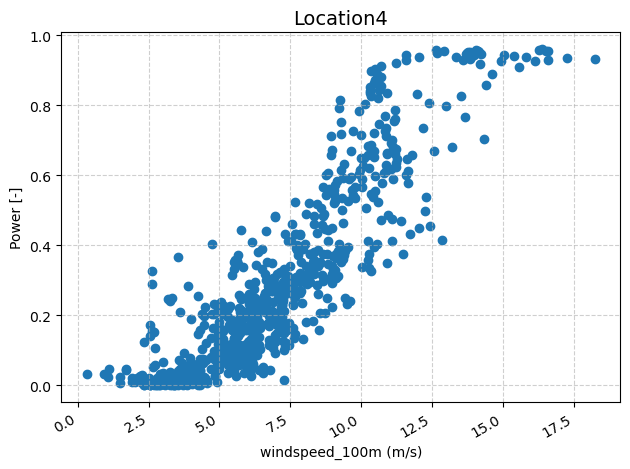

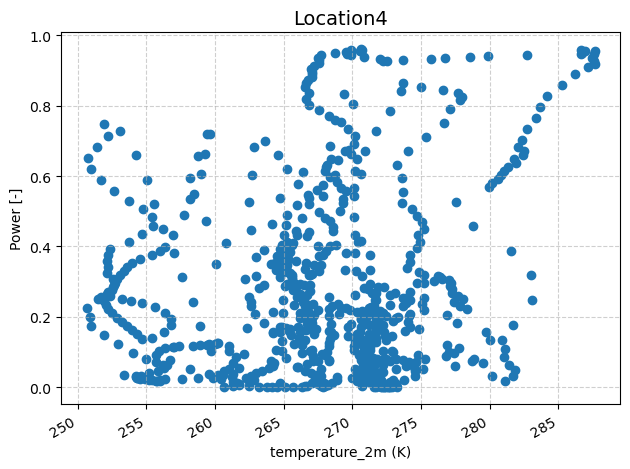

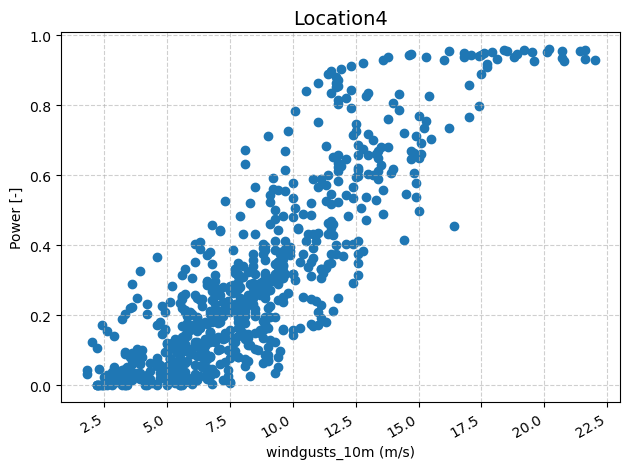

In [7]:
from plot_data import plot_power_features

Location = 'Location4'
time_s = '2017-12-01 00:00:00'
time_f = '2017-12-31 00:00:00'

plot_power_features(data_p,'windspeed_100m', Location, time_s, time_f)
plot_power_features(data_p,'temperature_2m', Location, time_s, time_f)
plot_power_features(data_p,'windgusts_10m', Location, time_s, time_f)

3- Persistence model

In [8]:
# Multiindex definition
data = data_p.set_index(['Time', 'Location'])

In [9]:
from persistence_model import pm_model

location = 1
time = '20200703 23'
power = pm_model(data, location, time)

print("Predicted power is", power)

Predicted power is 0.1912


#### Analysis of the correlations between variables to set relevant features

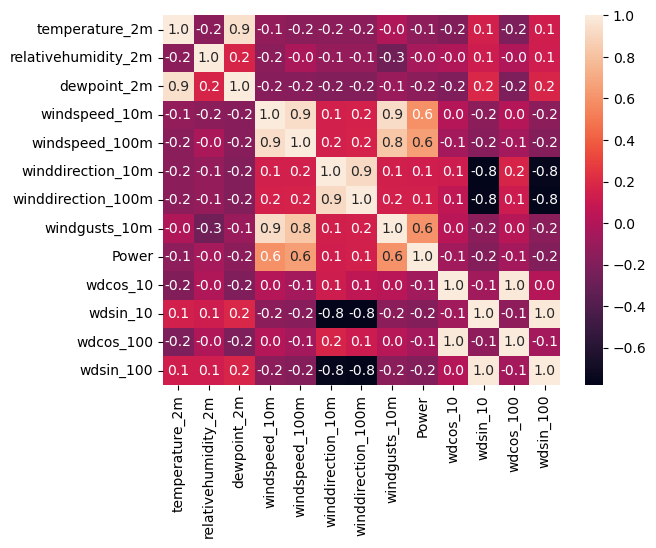

In [ ]:
from data_split import split_df
import seaborn

correlation_matrix = data.corr(numeric_only = True)
plt.figure()
seaborn.heatmap(correlation_matrix, annot = True, fmt = ".1f")

The correlation between power and the given features is only relevant in the case of wind speed (10 or 100m). We select wind speed at 100m for machine learning.

In [11]:
# filtering the data set to only 1 location
location = 1
location = "Location" + str(location)
df = data.xs(location, level = 'Location')

# getting the wind speed feature values 
X = df[['windspeed_100m', 'wdcos_100', 'wdsin_100']]

# Power 
y = df.Power

In [12]:
# NN model
from ML_models import NN_model
from metrics import metrics

n_splits = 2
sd = TimeSeriesSplit(n_splits=n_splits)
all_splits = list(sd.split(X))

for i in range(0,n_splits):
    i_train, i_test = all_splits[i]

    X_train = X.iloc[i_train].to_numpy()
    y_train = y.iloc[i_train].to_numpy()

    X_test = X.iloc[i_test].to_numpy()
    y_test = y.iloc[i_test].to_numpy()

power, NN_predictor = NN_model(X_train, y_train, X_test, y_test)
# print("MAE for SVM: ", metrics(y_test, power))



Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [13]:
# Cross validation results
cv_results = pd.DataFrame(NN_predictor.cv_results_)

In [14]:
# power predicted from NN model
y_NN = NN_predictor.predict(X_test)

In [15]:
# power predicted from persistence model
Time = X.iloc[i_test].index.to_list()

pm_predictions =[]
location = 1

for time in Time:

    temp = pm_model(data, location, time)
    pm_predictions.append(temp)

y_PM = pm_predictions


### Plot and compare results of the neural network model to the persistence model and the real data

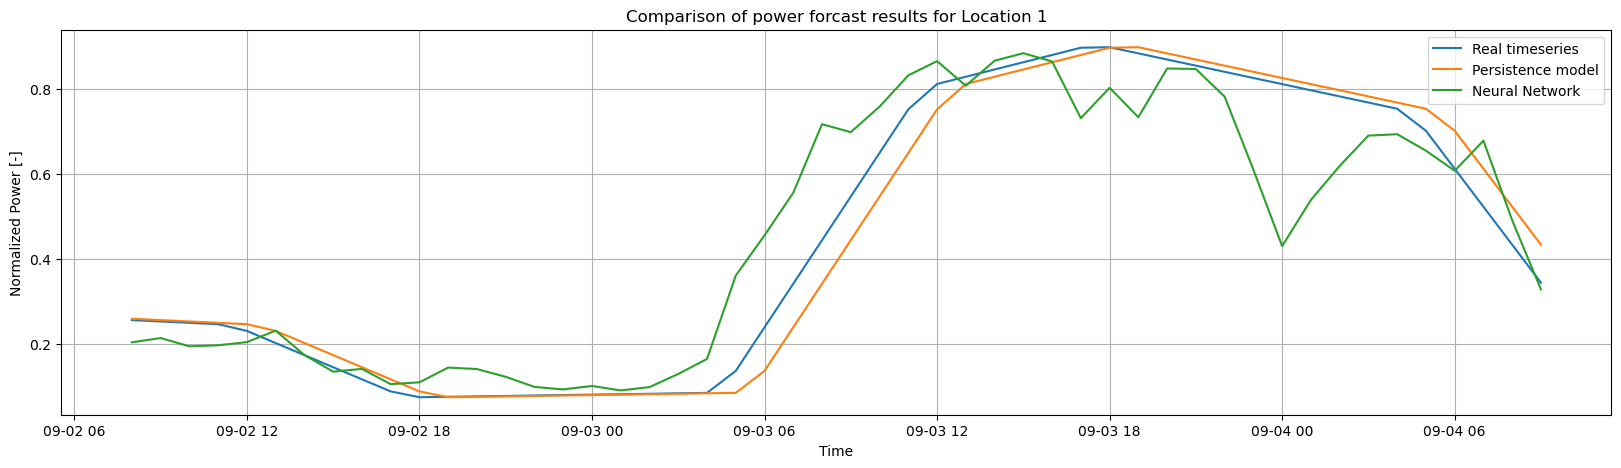

In [ ]:
plt.figure(figsize = (20, 5),)

nt = 50
plt.plot(Time[:nt], y_test[:nt], label = 'Real timeseries')
plt.plot(Time[:nt], y_PM[:nt], label = 'Persistence model')
plt.plot(Time[:nt], y_NN[:nt], label = 'Neural Network')

plt.xlabel('Time')
plt.ylabel('Normalized Power [-]')
plt.title('Comparison of power forcast results for Location 1')
plt.legend()
plt.grid()


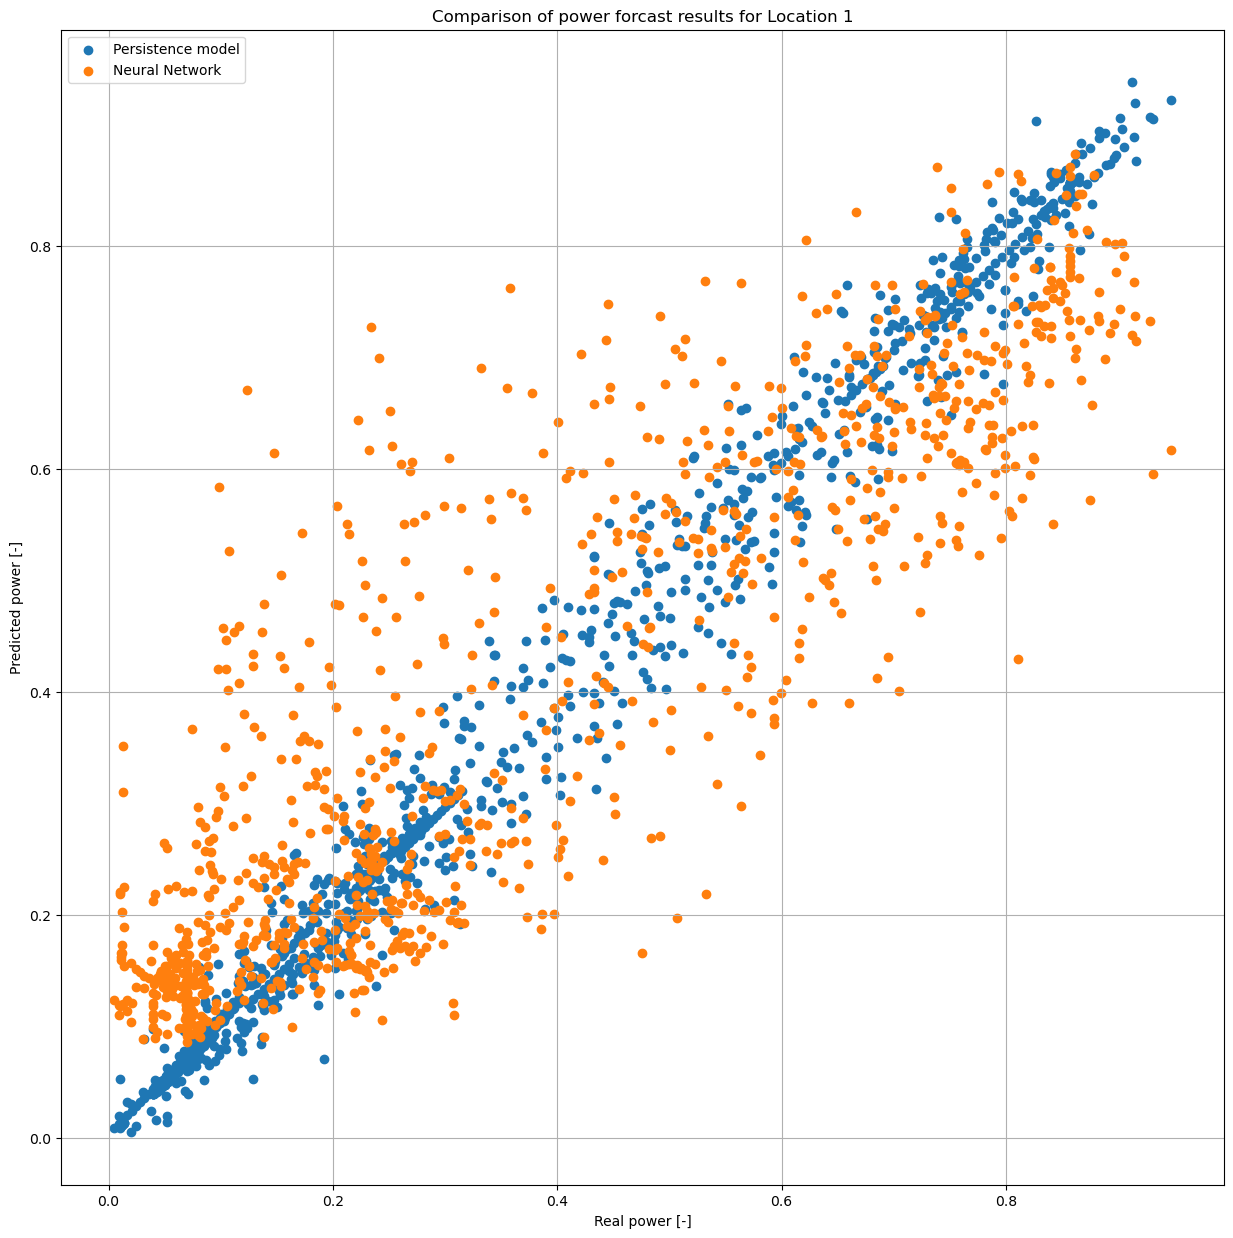

In [ ]:
plt.figure(figsize = (15, 15),)

nt = 1000
plt.scatter(y_test[:nt], y_PM[:nt], label = 'Persistence model')
plt.scatter(y_test[:nt], y_NN[:nt], label = 'Neural Network')

plt.xlabel('Real power [-]')
plt.ylabel('Predicted power [-]')
plt.title('Comparison of power forcast results for Location 1')
plt.legend()
plt.grid()


In [14]:
print("MAE, MSE, RMSE for NN: ", metrics(y_test, y_NN))
print("MAE, MSE, RMSE for PM: ", metrics(y_test, y_PM))

MAE, MSE, RMSE for NN:  (0.12585948682739342, 0.025927713695937077, 0.1610208486374888)
MAE, MSE, RMSE for PM:  (0.026431686643835613, 0.0013933080744863015, 0.037327042134172664)


In [15]:

from ML_models import svm_model 
power = svm_model(X_train, y_train, X_test, y_test)
#print("MAE for SVM: ", metrics(y_test, power))


Fitting 5 folds for each of 5 candidates, totalling 25 fits


KeyboardInterrupt: 